In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [2]:
f_1 = [[11.996, 11.959, 11.950, 11.653, 11.632],[13.927, 13.908, 13.665, 13.500, 13.429],[16.191, 16.000, 16.127, 15.935, 15.791],[17.976, 17.871, 18.149, 17.875, 18.057],[20.374, 20.220, 20.329, 20.145, 20.293],[22.510, 22.314, 22.969, 22.411, 22.669],[24.487, 24.605, 24.398, 24.759, 25.012],[26.695, 26.729, 27.075, 26.873, 27.165],[29.059, 29.078, 28.985, 28.865, 28.920],[31.353, 31.593, 31.349, 31.183, 31.472]]
f_2 = [[13.373, 13.730, 13.784, 13.896, 13.762],[16.020, 16.171, 16.199, 16.096, 15.838],[17.659, 17.983, 17.899, 17.980, 17.910],[20.266, 20.224, 20.210, 19.887, 19.893],[22.255, 22.044, 22.068, 21.997, 21.771],[24.717, 24.529, 24.448, 24.470, 24.519],[26.543, 26.303, 26.308, 26.597, 26.431],[28.617, 28.702, 28.519, 28.666, 28.704],[31.082, 31.075, 31.340, 31.328, 31.104],[33.308, 33.440, 33.420, 33.586, 33.489]]
U = [1.6 + i/5 for i in range(10)]#feszültségek V

In [3]:
f_1_atlagok = [np.average(i) for i in f_1]#1-es motor frekvenciája Hz
f_2_atlagok = [np.average(i) for i in f_2]#2-es motor frekvenciája Hz
f_1_hibak = [np.var(i) for i in f_1]
f_2_hibak = [np.var(i) for i in f_2]

In [4]:
def linearis(x, a, b):
        return x * a + b
def linearis_negyzet(x, a, b, c):
    return x * x * c + x * a + b
def linearis_gyok(x, a, b, c):
    return a * x + b + c * np.sqrt(x)

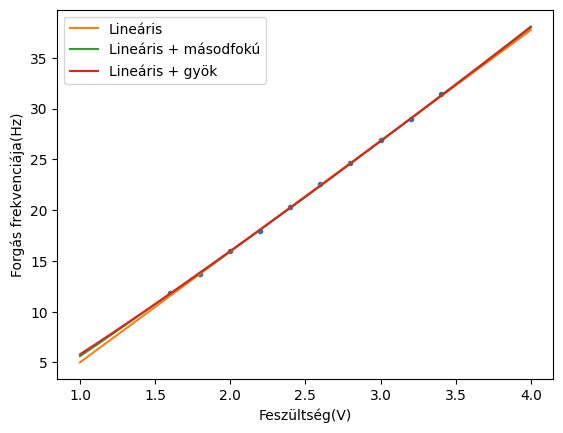

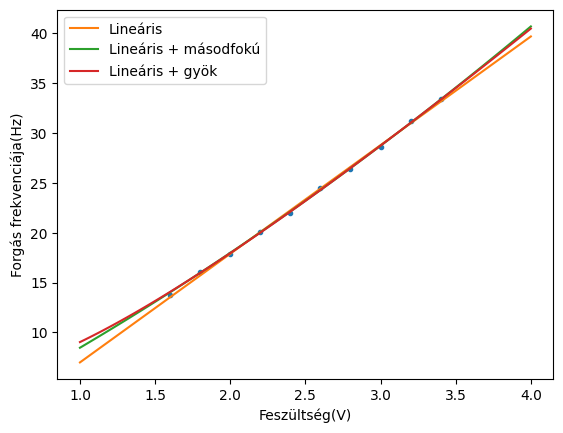

In [5]:
U_abrazolas = np.linspace(1, 4, 100)
illesztes_1 = [None for i in range(3)]
illesztes_1[0] = curve_fit(linearis, U, f_1_atlagok, sigma=f_1_hibak)
illesztes_1[1] = curve_fit(linearis_negyzet, U, f_1_atlagok, sigma=f_1_hibak)
illesztes_1[2] = curve_fit(linearis_gyok, U, f_1_atlagok, sigma=f_1_hibak)
illesztes_2 = [None for i in range(3)]
illesztes_2[0] = curve_fit(linearis, U, f_2_atlagok, sigma=f_2_hibak)
illesztes_2[1] = curve_fit(linearis_negyzet, U, f_2_atlagok, sigma=f_2_hibak)
illesztes_2[2] = curve_fit(linearis_gyok, U, f_2_atlagok, sigma=f_2_hibak)
plt.plot(U,f_1_atlagok, ".")
plt.plot(U_abrazolas, linearis(U_abrazolas, illesztes_1[0][0][0], illesztes_1[0][0][1]), label="Lineáris")
plt.plot(U_abrazolas, linearis_negyzet(U_abrazolas, illesztes_1[1][0][0], illesztes_1[1][0][1], illesztes_1[1][0][2]), label="Lineáris + másodfokú")
plt.plot(U_abrazolas, linearis_gyok(U_abrazolas, illesztes_1[2][0][0], illesztes_1[2][0][1], illesztes_1[2][0][2]), label="Lineáris + gyök")
plt.legend()
plt.xlabel("Feszültség(V)")
plt.ylabel("Forgás frekvenciája(Hz)")
plt.show()
plt.plot(U,f_2_atlagok, ".")
plt.plot(U_abrazolas, linearis(U_abrazolas, illesztes_2[0][0][0], illesztes_2[0][0][1]), label="Lineáris")
plt.plot(U_abrazolas, linearis_negyzet(U_abrazolas, illesztes_2[1][0][0], illesztes_2[1][0][1], illesztes_2[1][0][2]), label="Lineáris + másodfokú")
plt.plot(U_abrazolas, linearis_gyok(U_abrazolas, illesztes_2[2][0][0], illesztes_2[2][0][1], illesztes_2[2][0][2]), label="Lineáris + gyök")
plt.legend()
plt.xlabel("Feszültség(V)")
plt.ylabel("Forgás frekvenciája(Hz)")
plt.show()

In [6]:
for i in illesztes_1:
    print(i[0])
for i in illesztes_2:
    print(i[0])



[10.90802691 -5.90414757]
[ 9.63485437 -4.25778225  0.2380631 ]
[13.09119058 -0.20552651 -7.08460039]
[10.90622707 -3.92400658]
[7.69029972 0.15252026 0.61213586]
[ 16.90563876  11.36738474 -19.24930006]


In [7]:
for i in illesztes_1:
    print(np.sqrt(np.diag(i[1])))
for i in illesztes_2:
    print(np.sqrt(np.diag(i[1])))

[0.05679385 0.15516873]
[0.63278629 0.82647679 0.11797616]
[1.08090207 2.82170282 3.50414815]
[0.15818524 0.45946552]
[1.12444335 1.45642991 0.21291943]
[2.32207596 5.92093756 7.4403465 ]


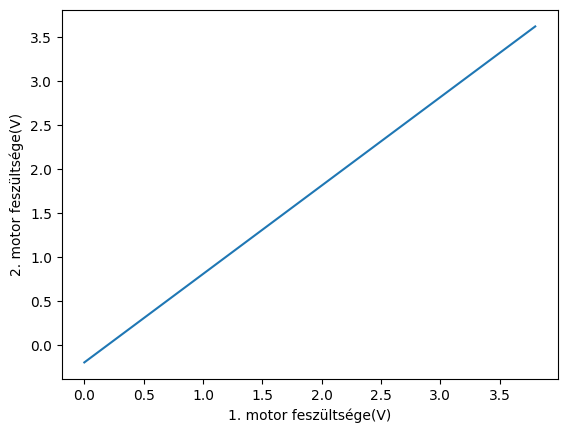

In [8]:
feszultseg_1 = np.linspace(0, 3.8, 100)
fordulatszamok = linearis(feszultseg_1, 10.90802691, -5.90414757)
feszultseg_2 = (fordulatszamok - -3.77946665) / 10.87306666
plt.plot(feszultseg_1, feszultseg_2)
plt.xlabel("1. motor feszültsége(V)")
plt.ylabel("2. motor feszültsége(V)")
plt.show()

In [9]:
kalibracio_illesztes = [None,None,None]
kalibracio_illesztes[0] = curve_fit(linearis, feszultseg_1, feszultseg_2)
kalibracio_illesztes[1] = curve_fit(linearis_negyzet, feszultseg_1, feszultseg_2)
kalibracio_illesztes[2] = curve_fit(linearis_gyok, feszultseg_1, feszultseg_2)

print(kalibracio_illesztes[0][0])
print(np.sqrt(np.diag(kalibracio_illesztes[0][1])))
print(kalibracio_illesztes[1][0])
print(np.sqrt(np.diag(kalibracio_illesztes[1][1])))
print(kalibracio_illesztes[2][0])
print(np.sqrt(np.diag(kalibracio_illesztes[2][1])))

[ 1.00321531 -0.1954077 ]
[2.55450578e-17 5.61854411e-17]
[ 1.00321531e+00 -1.95407700e-01 -9.15156985e-10]
[9.35996565e-11 2.02644848e-10 7.95454409e-12]
[ 1.00321530e+00 -1.95407701e-01  7.74777599e-09]
[7.52290643e-11 1.61674899e-10 5.91459144e-11]


In [10]:
print(f_1_atlagok[2])

16.0088


In [11]:
d = np.array([52.6, 50.6, 46.0, 56.9, 62.0, 71.2, 31.6, 53.3, 59.4, 62.8])#távolság cm
tt=np.array([7.314, 5.289, 6.943, 7.557, 7.901, 6.179, 5.787, 7.536, 5.872, 5.978])#mért idő s
dT=np.array([0.222, 0.180, 0.191, 0.232, 0.254, 0.191, 0.138, 0.127, 0.223, 0.212])#idő hibája s
nn=np.array([4, 3, 4, 4, 4, 3, 4, 4, 3, 3])

In [12]:
dd = 58.7/100 #távolság
uu_1 = np.array([1.6, 1.7, 1.8, 1.9, 2.0, 2.1, 2.2, 2.3, 2.4, 2.5])#1-es motor feszültsége V
uu_2= np.array([1.42, 1.52, 1.62, 1.72, 1.82, 1.92, 2.02, 2.12, 2.22, 2.32])#2-es motor feszültsége V
t = np.array([5.967, 7.685, 9.667, 9.688, 9.561, 9.540, 9.582, 9.571, 9.656, 7.748])# mért idó s
dt = np.array([0.286, 0.254, 0.191, 0.192, 0.180, 0.159, 0.191,0.212, 0.180, 0.170])# idó hibája s
n=np.array([3, 4, 5, 5, 5, 5, 5, 5, 5, 5, 4])

In [13]:
def T(l, K, alpha):
    return K * l ** alpha

In [14]:
d /= 100

In [15]:
for i in range(len(t)):
    tt[i] = tt[i]/nn[i]
for i in range(len(t)):
    t[i] = t[i]/n[i]
for i in range(len(dT)):
    dT[i] = dT[i]/nn[i]
for i in range(len(dt)):
    dt[i] = dt[i]/n[i]

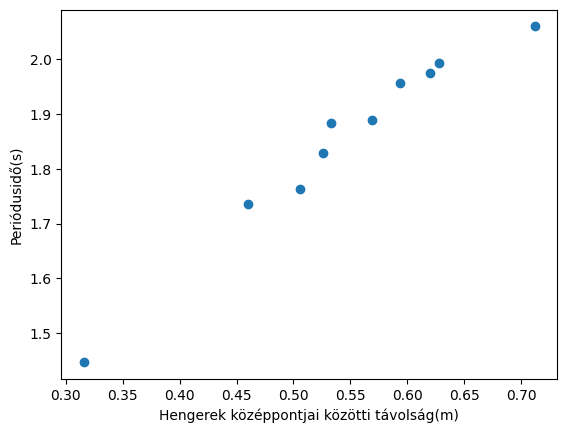

In [16]:
plt.scatter(d, tt)
plt.xlabel("Hengerek középpontjai közötti távolság(m)")
plt.ylabel("Periódusidő(s)")
plt.show()

In [17]:
hossz_illesztes = curve_fit(T, d, tt, sigma=dT)# type: ignore
print(hossz_illesztes[0])
print(np.sqrt(np.diag(hossz_illesztes[1])))

[2.45987676 0.45409613]
[0.03842954 0.02231953]


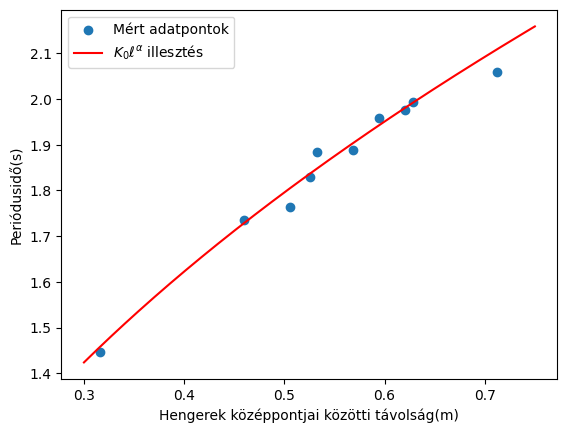

In [18]:
tavolsag_minta = np.linspace(0.30, 0.75, 200)
plt.scatter(d, tt, label="Mért adatpontok")
plt.plot(tavolsag_minta, T(tavolsag_minta, hossz_illesztes[0][0], hossz_illesztes[0][1]), label="$K_0\\ell^{\\alpha}$ illesztés", c="red")
plt.xlabel("Hengerek középpontjai közötti távolság(m)")
plt.ylabel("Periódusidő(s)")
plt.legend()
plt.show()

In [19]:
def T_05(l, K):
    return K * l ** (1/2)

In [20]:
hossz_illesztes_05 = curve_fit(T_05, d, tt, sigma=dT)
print(hossz_illesztes_05[0])
print(np.sqrt(np.diag(hossz_illesztes_05[1])))

[2.53555221]
[0.01470517]


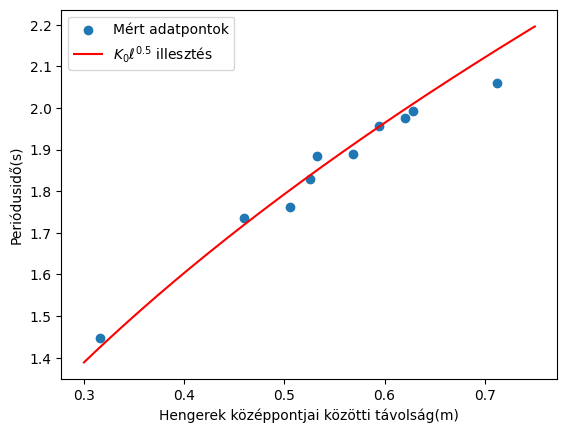

In [21]:

plt.scatter(d, tt, label="Mért adatpontok")
plt.plot(tavolsag_minta, T_05(tavolsag_minta, hossz_illesztes_05[0]), label="$K_0\\ell^{0.5}$ illesztés", c="red")
plt.xlabel("Hengerek középpontjai közötti távolság(m)")
plt.ylabel("Periódusidő(s)")
plt.legend()
plt.show()

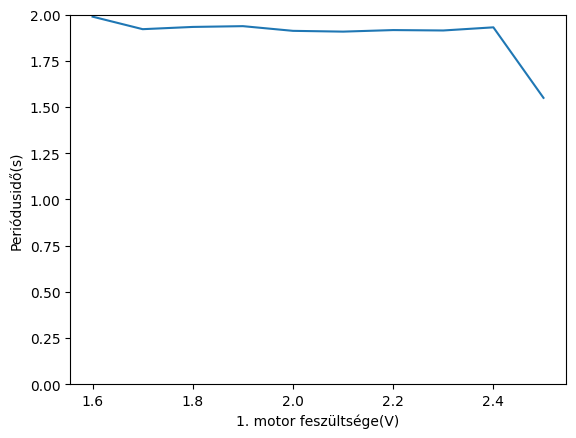

In [22]:
plt.plot(uu_1, t)
plt.ylim(0,2)
plt.xlabel("1. motor feszültsége(V)")
plt.ylabel("Periódusidő(s)")
plt.show()

In [23]:
mu =  ((2 * np.pi) ** (1/hossz_illesztes[0][1])) / (np.sqrt(8) * 9.81 * (hossz_illesztes[0][0] ** (1/hossz_illesztes[0][1])))
print(mu)
mu_05 = 4 * np.pi * np.pi / (np.sqrt(8) * 9.81 * hossz_illesztes_05[0][0] ** 2)
print(mu_05)

0.2842228049207134
0.2213097879364227


In [24]:
for i in range(len(f_2)):
    print(U[i], end=" & ")
    for j in range(len(f_2[i]) - 1):
        print(f_2[i][j], end=" & ")
    print(f_2[i][-1], end=" ")
    print("\\\\")

1.6 & 13.373 & 13.73 & 13.784 & 13.896 & 13.762 \\
1.8 & 16.02 & 16.171 & 16.199 & 16.096 & 15.838 \\
2.0 & 17.659 & 17.983 & 17.899 & 17.98 & 17.91 \\
2.2 & 20.266 & 20.224 & 20.21 & 19.887 & 19.893 \\
2.4000000000000004 & 22.255 & 22.044 & 22.068 & 21.997 & 21.771 \\
2.6 & 24.717 & 24.529 & 24.448 & 24.47 & 24.519 \\
2.8 & 26.543 & 26.303 & 26.308 & 26.597 & 26.431 \\
3.0 & 28.617 & 28.702 & 28.519 & 28.666 & 28.704 \\
3.2 & 31.082 & 31.075 & 31.34 & 31.328 & 31.104 \\
3.4000000000000004 & 33.308 & 33.44 & 33.42 & 33.586 & 33.489 \\


In [25]:
for i in range(len(f_2_atlagok)):
    print(U[i], end=" & ")
    print(f_2_atlagok[i], end=" & ")
    print(f_2_hibak[i], end=" ")
    print("\\\\")

1.6 & 13.709 & 0.03134800000000019 \\
1.8 & 16.064799999999998 & 0.016741360000000143 \\
2.0 & 17.8862 & 0.014103760000000142 \\
2.2 & 20.095999999999997 & 0.028633999999999837 \\
2.4000000000000004 & 22.027 & 0.024077999999999856 \\
2.6 & 24.5366 & 0.009039439999999937 \\
2.8 & 26.436400000000003 & 0.014293440000000015 \\
3.0 & 28.6416 & 0.004754640000000134 \\
3.2 & 31.1858 & 0.014748159999999986 \\
3.4000000000000004 & 33.4486 & 0.008234239999999872 \\


In [26]:
ulom = (uu_1 * 10.908 -5.904+3.924)/10.906
for i in range(len(ulom)):
    print(uu_1[i], end=" & ")
    print(ulom[i], end=" ")
    print("\\\\")

1.6 & 1.418741976893453 \\
1.7 & 1.5187603154227027 \\
1.8 & 1.6187786539519529 \\
1.9 & 1.7187969924812025 \\
2.0 & 1.8188153310104527 \\
2.1 & 1.9188336695397028 \\
2.2 & 2.018852008068953 \\
2.3 & 2.1188703465982024 \\
2.4 & 2.2188886851274523 \\
2.5 & 2.3189070236567026 \\


In [27]:
for i in range(len(d)):
    print(d[i], end=" & ")
    print(tt[i]*nn[i], end=" & ")
    print(dT[i]*nn[i], end=" & ")
    print(nn[i], end="")
    print("\\\\")

0.526 & 7.314 & 0.222 & 4\\
0.506 & 5.289 & 0.18 & 3\\
0.46 & 6.943 & 0.191 & 4\\
0.569 & 7.557 & 0.232 & 4\\
0.62 & 7.901 & 0.254 & 4\\
0.7120000000000001 & 6.179 & 0.191 & 3\\
0.316 & 5.787 & 0.138 & 4\\
0.5329999999999999 & 7.536 & 0.127 & 4\\
0.594 & 5.872 & 0.223 & 3\\
0.628 & 5.978 & 0.21200000000000002 & 3\\


In [28]:
for i in range(len(t)):
    print(uu_1[i], end=" & ")
    print(uu_2[i], end=" & ")
    print(t[i]*n[i], end=" & ")
    print(dt[i]*n[i], end=" & ")
    print(n[i], end=" ")
    print("\\\\")

1.6 & 1.42 & 5.967 & 0.286 & 3 \\
1.7 & 1.52 & 7.685 & 0.254 & 4 \\
1.8 & 1.62 & 9.667 & 0.191 & 5 \\
1.9 & 1.72 & 9.688 & 0.192 & 5 \\
2.0 & 1.82 & 9.561 & 0.18 & 5 \\
2.1 & 1.92 & 9.54 & 0.159 & 5 \\
2.2 & 2.02 & 9.582 & 0.191 & 5 \\
2.3 & 2.12 & 9.571 & 0.212 & 5 \\
2.4 & 2.22 & 9.656 & 0.18 & 5 \\
2.5 & 2.32 & 7.748 & 0.17 & 5 \\
